# Analisis Data: Smart Nutrition Tracker for Golden Age Children
**Coding Camp 2026 powered by DBS Foundation**

| | |
|---|---|
| **ID Tim** | CC26-PSU388 |
| **Tema** | Healthy Lives & Well-being |
| **Proyek** | Smart Nutrition Tracker for Golden Age Children |
| **Data Scientist** |  Regina Arija Zuhra & Alfian Anggara Putra Afandy |

---

## Latar Belakang

Permasalahan gizi pada anak usia dini masih menjadi isu kesehatan yang signifikan di Indonesia. Periode golden age (0-6 tahun) merupakan fase krusial karena pada masa ini pertumbuhan fisik dan perkembangan kognitif anak berlangsung sangat cepat. Namun, pemantauan asupan gizi anak masih belum dilakukan secara konsisten oleh orang tua, baik karena keterbatasan pemahaman maupun metode pencatatan yang cenderung rumit.

Notebook ini bertujuan untuk melakukan analisis data komposisi pangan Indonesia dan kebutuhan gizi anak usia 0-6 tahun guna menghasilkan insight yang dapat mendukung pengembangan sistem Smart Nutrition Tracker.

## Business Questions

Berikut adalah business questions yang akan dijawab melalui analisis data, disusun berdasarkan kriteria SMART (Specific, Measurable, Achievable, Relevant, Time-bound):

---

**BQ 1**: Apa 10 bahan makanan Indonesia dengan kandungan energi tertinggi per 100 gram berdasarkan data TKPI 2017?
- **Specific**: Berfokus pada kandungan energi, top 10 bahan makanan, per 100 gram
- **Measurable**: Diukur dalam satuan kalori (Kal)
- **Achievable**: Data energi tersedia lengkap di dataset TKPI
- **Relevant**: Energi merupakan nutrisi utama yang dibutuhkan untuk tumbuh kembang anak golden age
- **Time-bound**: Berdasarkan data TKPI 2017, Kemenkes RI

---

**BQ 2**: Kelompok makanan mana yang memiliki rata-rata kandungan protein tertinggi berdasarkan data TKPI 2017?
- **Specific**: Berfokus pada kandungan protein per kelompok makanan
- **Measurable**: Diukur dalam rata-rata gram protein per 100 gram
- **Achievable**: Kolom kategori dan protein tersedia di dataset
- **Relevant**: Protein berperan penting dalam pertumbuhan sel dan jaringan anak usia 0-6 tahun
- **Time-bound**: Berdasarkan data TKPI 2017, Kemenkes RI

---

**BQ 3**: Bahan makanan lokal apa yang paling memenuhi kebutuhan AKG energi, protein, dan karbohidrat anak usia 0-6 tahun per 100 gram?
- **Specific**: Berfokus pada 3 nutrisi utama (energi, protein, karbohidrat) untuk kelompok umur 0-6 tahun
- **Measurable**: Diukur dalam persentase pemenuhan AKG (%)
- **Achievable**: Dapat dihitung dari kombinasi dataset TKPI dan AKG
- **Relevant**: Langsung menjawab research question proyek tentang estimasi kandungan nutrisi makanan
- **Time-bound**: Berdasarkan TKPI 2017 dan AKG 2019 (Permenkes No. 28 Tahun 2019)

---

**BQ 4**: Nutrisi apa yang paling banyak tidak terpenuhi pada bahan makanan Indonesia jika dibandingkan dengan AKG anak usia 0-6 tahun?
- **Specific**: Membandingkan seluruh nutrisi dataset dengan threshold AKG anak 0-6 tahun
- **Measurable**: Diukur dari persentase jumlah bahan makanan yang berada di bawah threshold AKG (%)
- **Achievable**: Dapat dihitung dari kombinasi kedua dataset
- **Relevant**: Menjawab research question tentang identifikasi potensi kekurangan gizi
- **Time-bound**: Berdasarkan TKPI 2017 dan AKG 2019 (Permenkes No. 28 Tahun 2019)

---

**BQ 5**: Apa rekomendasi 5 bahan makanan lokal terbaik untuk memenuhi kebutuhan gizi anak usia 0-6 tahun berdasarkan kombinasi energi, protein, kalsium, dan zat besi?
- **Specific**: Berfokus pada 4 nutrisi kunci dan menghasilkan top 5 rekomendasi makanan
- **Measurable**: Diukur menggunakan skor normalisasi gabungan (0-1)
- **Achievable**: Dapat dihitung dari dataset TKPI menggunakan teknik normalisasi
- **Relevant**: Langsung menjawab research question tentang rekomendasi menu untuk orang tua
- **Time-bound**: Berdasarkan TKPI 2017 dan AKG 2019 (Permenkes No. 28 Tahun 2019)

## 1. Data Wrangling
### 1.1 Gathering Data

Dataset yang digunakan dalam analisis ini terdiri dari dua sumber:

1. **Dataset Komposisi Pangan (TKPI 2017)** : diperoleh melalui web scraping dari panganku.org. Proses scraping dilakukan pada notebook `01_Gathering.ipynb`.
2. **Dataset AKG Anak (AKG 2019)** : dibuat berdasarkan Peraturan Menteri Kesehatan RI No. 28 Tahun 2019 tentang Angka Kecukupan Gizi yang Dianjurkan untuk Masyarakat Indonesia.

In [248]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df_pangan = pd.read_csv('panganku_dataset.csv')
df_akg = pd.read_csv('akg_anak.csv')

print('Dataset Komposisi Pangan:')
print(f'Shape: {df_pangan.shape}')
print(df_pangan.head())

print('\nDataset AKG Anak:')
print(f'Shape: {df_akg.shape}')
print(df_akg.head())

Dataset Komposisi Pangan:
Shape: (1146, 28)
    Kode                                     Nama          Nama Latin  \
0  GP053                             Abon haruwan                 NaN   
1  GP054                                Abon ikan                 NaN   
2  DR001  Akar tonjong, segar (Lotus root, fresh)    Nelumbo nucifera   
3  DR002                          Ale,toge, segar  Acacia leucophloea   
4  ER001          Alpukat, segar (Avocado, fresh)    Persea americana   

                         Asal               Kategori          Tipe Bahan  \
0  Daerah Istimewa Yogyakarta                   Buah        Mentah (Raw)   
1                         NaN  Ikan/Kerang/Udang dll  Olahan (Processed)   
2                         NaN                Sayuran        Mentah (Raw)   
3                         NaN                Sayuran        Mentah (Raw)   
4                         NaN                   Buah        Mentah (Raw)   

             Keterangan Air (Water) Energi (Energy) Protein 

### 1.2 Assessing Data

Pada tahap ini dilakukan pengecekan kualitas data meliputi:
- Tipe data setiap kolom
- Jumlah missing values
- Data duplikat
- Statistik deskriptif

In [249]:
# Informasi umum dataset
print('=== INFO DATASET KOMPOSISI PANGAN ===')
print(df_pangan.info())

=== INFO DATASET KOMPOSISI PANGAN ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1146 entries, 0 to 1145
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Kode                      1146 non-null   object
 1   Nama                      1146 non-null   object
 2   Nama Latin                510 non-null    object
 3   Asal                      153 non-null    object
 4   Kategori                  1146 non-null   object
 5   Tipe Bahan                1146 non-null   object
 6   Keterangan                238 non-null    object
 7   Air (Water)               1144 non-null   object
 8   Energi (Energy)           1146 non-null   object
 9   Protein (Protein)         1145 non-null   object
 10  Lemak (Fat)               1145 non-null   object
 11  Karbohidrat (CHO)         1146 non-null   object
 12  Abu (ASH)                 1146 non-null   object
 13  Kalsium (Ca)              1106 non-null 

In [250]:
# Cek missing values
print('=== MISSING VALUES ===')
print(df_pangan.isnull().sum())

=== MISSING VALUES ===
Kode                          0
Nama                          0
Nama Latin                  636
Asal                        993
Kategori                      0
Tipe Bahan                    0
Keterangan                  908
Air (Water)                   2
Energi (Energy)               0
Protein (Protein)             1
Lemak (Fat)                   1
Karbohidrat (CHO)             0
Abu (ASH)                     0
Kalsium (Ca)                 40
Fosfor (P)                   40
Besi (Fe)                    43
Natrium (Na)                282
Kalium (K)                  323
Tembaga (Cu)                351
Seng (Zn)                   347
Riboflavin (Vit. B2)        350
Niasin (Niacin)             339
Serat (Fibre)               221
Retinol (Vit. A)            605
Beta-Karoten (Carotenes)    467
Karoten Total (Re)          539
Thiamin (Vit. B1)            88
Vitamin C (Vit. C)          289
dtype: int64


In [251]:
# Cek duplikat
print('=== DUPLIKAT ===')
print(f'Jumlah baris duplikat: {df_pangan.duplicated().sum()}')

=== DUPLIKAT ===
Jumlah baris duplikat: 0


In [252]:
# Statistik deskriptif
print('=== STATISTIK DESKRIPTIF ===')
print(df_pangan.describe())

=== STATISTIK DESKRIPTIF ===
         Kode          Nama  Nama Latin  Asal Kategori          Tipe Bahan  \
count    1146          1146         510   153     1146                1146   
unique   1146          1146         306    76       13                   2   
top     GP053  Abon haruwan  Bos taurus  Aceh  Sayuran  Olahan (Processed)   
freq        1             1           9     9      227                 587   

                                               Keterangan Air (Water)  \
count                                                 238        1144   
unique                                                236         556   
top     Seperti kue mangkok. Berbahan dasar tepung ber...    : 80.0 g   
freq                                                    2          11   

       Energi (Energy) Protein (Protein)  ... Tembaga (Cu) Seng (Zn)  \
count             1146              1145  ...          795       799   
unique             426               299  ...          121        77  

#### Hasil Assessing

Berdasarkan pengecekan di atas, ditemukan beberapa masalah kualitas data:

1. **Format nilai nutrisi** : nilai nutrisi masih mengandung prefix `: ` dan satuan (g, mg, Kal, mcg), perlu dipisah menjadi angka saja
2. **Missing values** : beberapa kolom nutrisi mikro memiliki missing values yang cukup banyak (Natrium, Kalium, Retinol, dll)
3. **Tipe data** : kolom nutrisi masih bertipe object karena mengandung satuan, perlu dikonversi ke numeric

### 1.3 Cleaning Data

Berdasarkan hasil assessing, dilakukan proses cleaning sebagai berikut:
1. Menghapus kolom duplikat (`kode`)
2. Membersihkan prefix `: ` dan satuan dari nilai nutrisi
3. Mengkonversi tipe data kolom nutrisi ke numeric
4. Menangani missing values

In [253]:
# 1. Hapus kolom duplikat jika ada
if 'kode' in df_pangan.columns:
    df_pangan = df_pangan.drop(columns=['kode'])
    print('Kolom duplikat kode dihapus')
else:
    print('Tidak ada kolom duplikat')

# 2. Bersihkan prefix ': ' dan satuan dari nilai nutrisi
import re

def clean_nilai(val):
    if pd.isna(val):
        return np.nan
    val = str(val)
    val = val.replace(':', '').strip()
    val = val.replace('Â', '').strip()
    match = re.search(r'[\d.]+', val)
    if match:
        return float(match.group())
    return np.nan

nutrisi_cols = [
    'Air (Water)', 'Energi (Energy)', 'Protein (Protein)', 'Lemak (Fat)',
    'Karbohidrat (CHO)', 'Serat (Fibre)', 'Abu (ASH)', 'Kalsium (Ca)',
    'Fosfor (P)', 'Besi (Fe)', 'Natrium (Na)', 'Kalium (K)', 'Tembaga (Cu)',
    'Seng (Zn)', 'Retinol (Vit. A)', 'Beta-Karoten (Carotenes)',
    'Karoten Total (Re)', 'Thiamin (Vit. B1)', 'Riboflavin (Vit. B2)',
    'Niasin (Niacin)', 'Vitamin C (Vit. C)'
]

for col in nutrisi_cols:
    if col in df_pangan.columns:
        df_pangan[col] = df_pangan[col].apply(clean_nilai)

print('Cleaning selesai!')
print(df_pangan[nutrisi_cols[:5]].head())

Tidak ada kolom duplikat
Cleaning selesai!
   Air (Water)  Energi (Energy)  Protein (Protein)  Lemak (Fat)  \
0         11.6            513.0               23.7         37.0   
1          6.4            435.0               27.2         20.2   
2         86.7             45.0                1.1          0.4   
3         90.6             37.0                4.4          0.5   
4         84.3             85.0                0.9          6.5   

   Karbohidrat (CHO)  
0               21.3  
1               36.1  
2               10.8  
3                3.8  
4                7.7  


#### Strategi Penanganan Missing Values

Penanganan missing values dilakukan berbeda untuk setiap tipe kolom:

**1. Kolom Nutrisi (numerik) : diisi dengan nilai Median**

Dipilih median (bukan mean) karena:
- Data nutrisi cenderung memiliki distribusi yang tidak simetris (skewed), 
  misalnya beberapa bahan makanan memiliki kandungan tertentu yang sangat 
  tinggi (outlier), sehingga mean akan tertarik ke arah outlier tersebut
- Median lebih robust terhadap outlier dan lebih merepresentasikan 
  nilai "tengah" yang sesungguhnya dari bahan makanan pada umumnya
- Missing values pada kolom nutrisi mikro (natrium, kalium, retinol, dll) 
  terjadi karena data memang tidak tersedia di sumber TKPI, bukan karena 
  kesalahan input, sehingga pengisian dengan median adalah pendekatan 
  yang wajar

**2. Kolom Teks (nama_latin, asal, keterangan) : diisi dengan '-'**

Dipilih tanda '-' karena:
- Kolom ini bersifat deskriptif dan tidak digunakan dalam perhitungan 
  atau pemodelan
- Mengisi dengan '-' menjaga kejelasan bahwa data memang tidak tersedia, 
  berbeda dengan string kosong yang bisa ambigu

In [254]:
# 3. Rename kolom biar lebih mudah dipakai
df_pangan = df_pangan.rename(columns={
    'Kode': 'kode',
    'Nama': 'nama',
    'Nama Latin': 'nama_latin',
    'Asal': 'asal',
    'Kategori': 'kategori',
    'Tipe Bahan': 'tipe',
    'Keterangan': 'keterangan',
    'Air (Water)': 'air_g',
    'Energi (Energy)': 'energi_kal',
    'Protein (Protein)': 'protein_g',
    'Lemak (Fat)': 'lemak_g',
    'Karbohidrat (CHO)': 'karbo_g',
    'Serat (Fibre)': 'serat_g',
    'Abu (ASH)': 'abu_g',
    'Kalsium (Ca)': 'kalsium_mg',
    'Fosfor (P)': 'fosfor_mg',
    'Besi (Fe)': 'besi_mg',
    'Natrium (Na)': 'natrium_mg',
    'Kalium (K)': 'kalium_mg',
    'Tembaga (Cu)': 'tembaga_mg',
    'Seng (Zn)': 'seng_mg',
    'Retinol (Vit. A)': 'retinol_mcg',
    'Beta-Karoten (Carotenes)': 'b_kar_mcg',
    'Karoten Total (Re)': 'kar_total_mcg',
    'Thiamin (Vit. B1)': 'thiamin_mg',
    'Riboflavin (Vit. B2)': 'riboflavin_mg',
    'Niasin (Niacin)': 'niasin_mg',
    'Vitamin C (Vit. C)': 'vit_c_mg'
})

print('Rename selesai!')
print(df_pangan.columns.tolist())

Rename selesai!
['kode', 'nama', 'nama_latin', 'asal', 'kategori', 'tipe', 'keterangan', 'air_g', 'energi_kal', 'protein_g', 'lemak_g', 'karbo_g', 'abu_g', 'kalsium_mg', 'fosfor_mg', 'besi_mg', 'natrium_mg', 'kalium_mg', 'tembaga_mg', 'seng_mg', 'riboflavin_mg', 'niasin_mg', 'serat_g', 'retinol_mcg', 'b_kar_mcg', 'kar_total_mcg', 'thiamin_mg', 'vit_c_mg']


In [255]:
# Cek hasil cleaning
print('=== HASIL CLEANING ===')
print(f'Shape: {df_pangan.shape}')
print(f'\nTipe data:')
print(df_pangan[nutrisi_cols_clean].dtypes)
print(f'\nSample data:')
print(df_pangan[['kode', 'nama', 'kategori', 'energi_kal', 'protein_g', 'lemak_g', 'karbo_g']].head())

=== HASIL CLEANING ===
Shape: (1146, 28)

Tipe data:
air_g            float64
energi_kal       float64
protein_g        float64
lemak_g          float64
karbo_g          float64
serat_g          float64
kalsium_mg       float64
fosfor_mg        float64
besi_mg          float64
natrium_mg       float64
kalium_mg        float64
tembaga_mg       float64
seng_mg          float64
retinol_mcg      float64
b_kar_mcg        float64
kar_total_mcg    float64
thiamin_mg       float64
riboflavin_mg    float64
niasin_mg        float64
vit_c_mg         float64
dtype: object

Sample data:
    kode                                     nama               kategori  \
0  GP053                             Abon haruwan                   Buah   
1  GP054                                Abon ikan  Ikan/Kerang/Udang dll   
2  DR001  Akar tonjong, segar (Lotus root, fresh)                Sayuran   
3  DR002                          Ale,toge, segar                Sayuran   
4  ER001          Alpukat, segar (Avoca

### 1.4 Data Dictionary

Berikut adalah penjelasan setiap kolom pada dataset yang digunakan dalam analisis:

In [256]:
data_dict = {
    'Kolom': [
        'kode', 'nama', 'nama_latin', 'asal', 'kategori', 'tipe', 'keterangan',
        'air_g', 'energi_kal', 'protein_g', 'lemak_g', 'karbo_g', 'serat_g', 'abu_g',
        'kalsium_mg', 'fosfor_mg', 'besi_mg', 'natrium_mg', 'kalium_mg',
        'tembaga_mg', 'seng_mg', 'retinol_mcg', 'b_kar_mcg', 'kar_total_mcg',
        'thiamin_mg', 'riboflavin_mg', 'niasin_mg', 'vit_c_mg'
    ],
    'Tipe Data': [
        'object', 'object', 'object', 'object', 'object', 'object', 'object',
        'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 'float64',
        'float64', 'float64', 'float64', 'float64', 'float64',
        'float64', 'float64', 'float64', 'float64', 'float64',
        'float64', 'float64', 'float64', 'float64'
    ],
    'Satuan': [
        '-', '-', '-', '-', '-', '-', '-',
        'gram', 'Kalori', 'gram', 'gram', 'gram', 'gram', 'gram',
        'miligram', 'miligram', 'miligram', 'miligram', 'miligram',
        'miligram', 'miligram', 'mikrogram', 'mikrogram', 'mikrogram',
        'miligram', 'miligram', 'miligram', 'miligram'
    ],
    'Deskripsi': [
        'Kode unik bahan makanan berdasarkan TKPI',
        'Nama bahan makanan dalam Bahasa Indonesia',
        'Nama ilmiah/latin bahan makanan',
        'Daerah asal bahan makanan',
        'Kelompok/kategori bahan makanan',
        'Tipe bahan makanan (mentah/olahan)',
        'Keterangan tambahan tentang bahan makanan',
        'Kandungan air per 100 gram bahan makanan',
        'Kandungan energi per 100 gram bahan makanan',
        'Kandungan protein per 100 gram bahan makanan',
        'Kandungan lemak per 100 gram bahan makanan',
        'Kandungan karbohidrat per 100 gram bahan makanan',
        'Kandungan serat pangan per 100 gram bahan makanan',
        'Kandungan abu per 100 gram bahan makanan',
        'Kandungan kalsium per 100 gram bahan makanan',
        'Kandungan fosfor per 100 gram bahan makanan',
        'Kandungan zat besi per 100 gram bahan makanan',
        'Kandungan natrium per 100 gram bahan makanan',
        'Kandungan kalium per 100 gram bahan makanan',
        'Kandungan tembaga per 100 gram bahan makanan',
        'Kandungan seng per 100 gram bahan makanan',
        'Kandungan retinol (Vitamin A) per 100 gram bahan makanan',
        'Kandungan beta-karoten per 100 gram bahan makanan',
        'Kandungan karoten total per 100 gram bahan makanan',
        'Kandungan thiamin (Vitamin B1) per 100 gram bahan makanan',
        'Kandungan riboflavin (Vitamin B2) per 100 gram bahan makanan',
        'Kandungan niasin per 100 gram bahan makanan',
        'Kandungan vitamin C per 100 gram bahan makanan'
    ]
}

df_dict = pd.DataFrame(data_dict)
df_dict.index += 1
print(f'Total kolom terdokumentasi: {len(df_dict)}')
df_dict

Total kolom terdokumentasi: 28


,Kolom,Tipe Data,Satuan,Deskripsi
1,kode,object,-,Kode unik bahan makanan berdasarkan TKPI
2,nama,object,-,Nama bahan makanan dalam Bahasa Indonesia
3,nama_latin,object,-,Nama ilmiah/latin bahan makanan
4,asal,object,-,Daerah asal bahan makanan
5,kategori,object,-,Kelompok/kategori bahan makanan
6,tipe,object,-,Tipe bahan makanan (mentah/olahan)
7,keterangan,object,-,Keterangan tambahan tentang bahan makanan
8,air_g,float64,gram,Kandungan air per 100 gram bahan makanan
9,energi_kal,float64,Kalori,Kandungan energi per 100 gram bahan makanan
10,protein_g,float64,gram,Kandungan protein per 100 gram bahan makanan


### 1.5 Final Dataset

Dataset yang telah melalui proses cleaning dan feature engineering akan disimpan dalam format CSV sebagai final dataset yang siap digunakan untuk proses pemodelan oleh tim AI Engineer. Proses penyimpanan dilakukan setelah feature engineering selesai agar seluruh fitur baru ikut tersimpan.

## 1.6 Feature Engineering

Pada tahap ini dibuat fitur-fitur baru yang lebih informatif berdasarkan kolom yang sudah ada. Fitur baru ini dirancang untuk mendukung proses pemodelan oleh tim AI Engineer, khususnya untuk klasifikasi status gizi dan deteksi potensi kekurangan nutrisi pada anak usia 0-6 tahun.

Fitur baru yang dibuat:
1. **status_energi** : status kecukupan energi berdasarkan AKG rata-rata anak 0-6 tahun
2. **status_protein** : status kecukupan protein berdasarkan AKG rata-rata anak 0-6 tahun
3. **status_kalsium** : status kecukupan kalsium berdasarkan AKG rata-rata anak 0-6 tahun
4. **status_besi** : status kecukupan zat besi berdasarkan AKG rata-rata anak 0-6 tahun
5. **skor_gizi_anak** : skor gabungan normalisasi dari energi, protein, kalsium, dan zat besi

In [257]:
from sklearn.preprocessing import MinMaxScaler

# AKG rata-rata anak 0-6 tahun
akg_rata = df_akg[df_akg['kelompok_umur'].isin(['1-3 tahun', '4-6 tahun'])][
    ['energi_kal', 'protein_g', 'kalsium_mg', 'besi_mg']
].mean()

print('AKG rata-rata anak 0-6 tahun:')
print(akg_rata)

# Fungsi klasifikasi status nutrisi
def status_nutrisi(nilai, threshold):
    if nilai < threshold * 0.5:
        return 'Kurang'
    elif nilai <= threshold:
        return 'Cukup'
    else:
        return 'Lebih'

# 1-4. Status per nutrisi
df_final['status_energi'] = df_final['energi_kal'].apply(
    lambda x: status_nutrisi(x, akg_rata['energi_kal']))
df_final['status_protein'] = df_final['protein_g'].apply(
    lambda x: status_nutrisi(x, akg_rata['protein_g']))
df_final['status_kalsium'] = df_final['kalsium_mg'].apply(
    lambda x: status_nutrisi(x, akg_rata['kalsium_mg']))
df_final['status_besi'] = df_final['besi_mg'].apply(
    lambda x: status_nutrisi(x, akg_rata['besi_mg']))

# 5. Skor gizi gabungan
scaler = MinMaxScaler()
cols_skor = ['energi_kal', 'protein_g', 'kalsium_mg', 'besi_mg']
df_norm = scaler.fit_transform(df_final[cols_skor])
df_final['skor_gizi_anak'] = df_norm.mean(axis=1).round(4)

print('\nDistribusi status_energi:')
print(df_final['status_energi'].value_counts())
print('\nDistribusi status_protein:')
print(df_final['status_protein'].value_counts())
print('\nDistribusi status_kalsium:')
print(df_final['status_kalsium'].value_counts())
print('\nDistribusi status_besi:')
print(df_final['status_besi'].value_counts())
print('\nSample skor_gizi_anak:')
print(df_final[['nama', 'skor_gizi_anak']].head(10))

AKG rata-rata anak 0-6 tahun:
energi_kal    1375.0
protein_g       22.5
kalsium_mg     825.0
besi_mg          8.5
dtype: float64

Distribusi status_energi:
status_energi
Kurang    1134
Cukup       12
Name: count, dtype: int64

Distribusi status_protein:
status_protein
Kurang    780
Cukup     241
Lebih     125
Name: count, dtype: int64

Distribusi status_kalsium:
status_kalsium
Kurang    1095
Cukup       41
Lebih       10
Name: count, dtype: int64

Distribusi status_besi:
status_besi
Kurang    911
Cukup     156
Lebih      79
Name: count, dtype: int64

Sample skor_gizi_anak:
                                      nama  skor_gizi_anak
0                             Abon haruwan          0.2287
1                                Abon ikan          0.2300
2  Akar tonjong, segar (Lotus root, fresh)          0.0359
3                          Ale,toge, segar          0.0410
4          Alpukat, segar (Avocado, fresh)          0.0295
5                            Amparan tatak          0.0746
6      

In [258]:
# Simpan final dataset dengan fitur baru
df_final.to_csv('final_dataset.csv', index=False)
print(f'Final dataset dengan fitur baru tersimpan!')
print(f'Shape: {df_final.shape}')
print(f'\nKolom baru: {["status_energi", "status_protein", "status_kalsium", "status_besi", "skor_gizi_anak"]}')
print(df_final.tail())

Final dataset dengan fitur baru tersimpan!
Shape: (1146, 33)

Kolom baru: ['status_energi', 'status_protein', 'status_kalsium', 'status_besi', 'skor_gizi_anak']
       kode                           nama        nama_latin        asal  \
1141  DP021                  Wortel, kukus                 -           -   
1142  DP020                  Wortel, rebus                 -           -   
1143  DR166  Wortel, segar (Carrot, fresh)  Daucus carota L.           -   
1144  AP114                         Yangko                 -  Yogyakarta   
1145  JP011                 Yoghurt, segar                 -           -   

      kategori                tipe  \
1141   Sayuran  Olahan (Processed)   
1142   Sayuran  Olahan (Processed)   
1143   Sayuran        Mentah (Raw)   
1144  Serealia  Olahan (Processed)   
1145      Susu  Olahan (Processed)   

                                             keterangan  air_g  energi_kal  \
1141                                                  -   89.5        37.0 

### Visualisasi Distribusi Fitur Baru

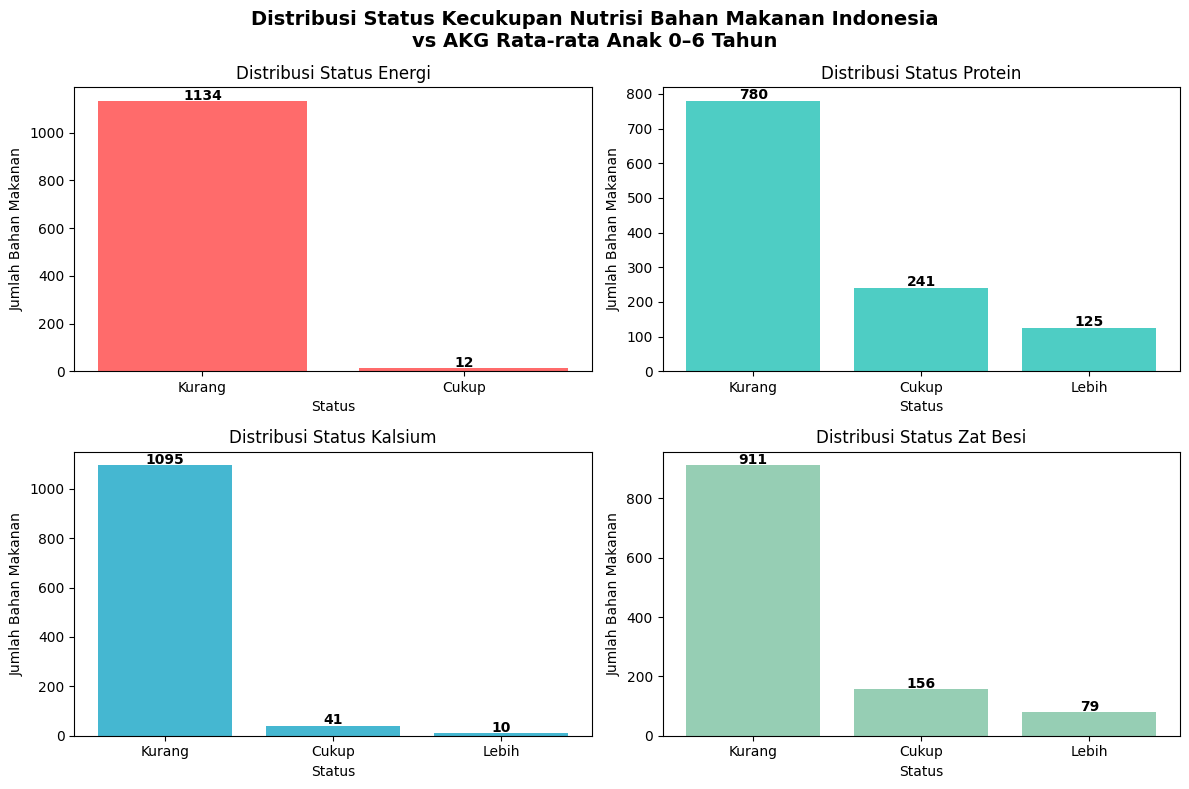

In [259]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

status_cols = ['status_energi', 'status_protein', 'status_kalsium', 'status_besi']
titles = ['Status Energi', 'Status Protein', 'Status Kalsium', 'Status Zat Besi']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for i, (col, title, color) in enumerate(zip(status_cols, titles, colors)):
    ax = axes[i//2][i%2]
    counts = df_final[col].value_counts()
    ax.bar(counts.index, counts.values, color=color)
    ax.set_title(f'Distribusi {title}')
    ax.set_xlabel('Status')
    ax.set_ylabel('Jumlah Bahan Makanan')
    for j, v in enumerate(counts.values):
        ax.text(j, v + 5, str(v), ha='center', fontweight='bold')

plt.suptitle('Distribusi Status Kecukupan Nutrisi Bahan Makanan Indonesia\nvs AKG Rata-rata Anak 0–6 Tahun', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight Feature Engineering:**

Hasil feature engineering menunjukkan bahwa sebagian besar bahan makanan Indonesia masih berada dalam status **Kurang** untuk semua nutrisi kunci jika dibandingkan dengan AKG rata-rata anak 0-6 tahun per 100 gram. Status energi paling dominan kurang dengan 1.134 dari 1.146 bahan makanan (98.9%), diikuti kalsium (1.095 bahan/95.5%), zat besi (911 bahan/79.5%), dan protein (780 bahan/68.1%).

Hal ini kembali menegaskan bahwa tidak ada satu bahan makanan pun yang dapat memenuhi seluruh kebutuhan gizi harian anak secara individual, sehingga variasi dan kombinasi menu menjadi kunci utama dalam pemenuhan gizi anak golden age.

Fitur `skor_gizi_anak` yang dihasilkan dari normalisasi gabungan energi, protein, kalsium, dan zat besi dapat digunakan oleh tim AI Engineer sebagai target variabel atau fitur tambahan dalam pengembangan model klasifikasi status nutrisi.

## 2. Exploratory Data Analysis (EDA)

Pada tahap ini dilakukan analisis eksplorasi data untuk menjawab business questions yang telah ditetapkan.

### BQ 1: Apa 10 bahan makanan Indonesia dengan kandungan energi tertinggi per 100 gram?

C:\Users\regina\AppData\Local\Temp\ipykernel_5836\755856552.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_energi, x='energi_kal', y='nama', palette='Oranges_r')


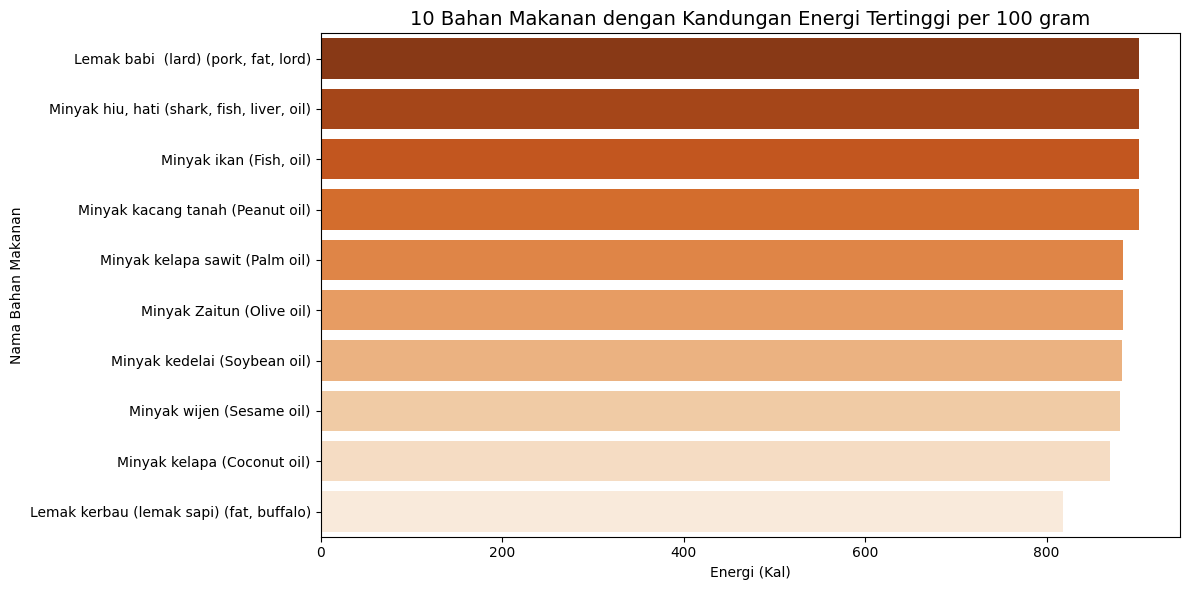

                                      nama     kategori  energi_kal
      Lemak babi  (lard) (pork, fat, lord) Minyak/Lemak       902.0
Minyak hiu, hati (shark, fish, liver, oil) Minyak/Lemak       902.0
                   Minyak ikan (Fish, oil) Minyak/Lemak       902.0
          Minyak kacang tanah (Peanut oil) Minyak/Lemak       902.0
            Minyak kelapa sawit (Palm oil) Minyak/Lemak       884.0
                 Minyak Zaitun (Olive oil) Minyak/Lemak       884.0
              Minyak kedelai (Soybean oil) Minyak/Lemak       883.0
                 Minyak wijen (Sesame oil) Minyak/Lemak       881.0
               Minyak kelapa (Coconut oil) Minyak/Lemak       870.0
  Lemak kerbau (lemak sapi) (fat, buffalo) Minyak/Lemak       818.0


In [260]:
# BQ 1 - Top 10 bahan makanan dengan energi tertinggi
top10_energi = df_pangan.nlargest(10, 'energi_kal')[['nama', 'kategori', 'energi_kal']]

plt.figure(figsize=(12, 6))
sns.barplot(data=top10_energi, x='energi_kal', y='nama', palette='Oranges_r')
plt.title('10 Bahan Makanan dengan Kandungan Energi Tertinggi per 100 gram', fontsize=14)
plt.xlabel('Energi (Kal)')
plt.ylabel('Nama Bahan Makanan')
plt.tight_layout()
plt.show()

print(top10_energi.to_string(index=False))

**Insight BQ 1:**

10 bahan makanan dengan kandungan energi tertinggi per 100 gram didominasi oleh kelompok **Minyak/Lemak**, dengan nilai energi berkisar antara 818-902 Kal per 100 gram. Lemak babi (lard), Minyak hiu, dan Minyak ikan menempati posisi teratas dengan nilai energi tertinggi yaitu 902 Kal per 100 gram.

Tingginya kandungan energi pada kelompok minyak dan lemak disebabkan oleh kandungan lemak yang sangat tinggi, di mana 1 gram lemak menghasilkan 9 Kal - jauh lebih tinggi dibandingkan karbohidrat dan protein yang masing-masing hanya menghasilkan 4 Kal per gram.

Meskipun tinggi energi, bahan makanan dari kelompok minyak/lemak **tidak direkomendasikan sebagai sumber energi utama** untuk anak golden age karena minim nutrisi esensial lainnya seperti protein, vitamin, dan mineral yang dibutuhkan untuk tumbuh kembang optimal.

### BQ 2: Kelompok makanan mana yang memiliki rata-rata kandungan protein tertinggi?

C:\Users\regina\AppData\Local\Temp\ipykernel_5836\876182757.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_protein, x='protein_g', y='kategori', palette='Blues_r')


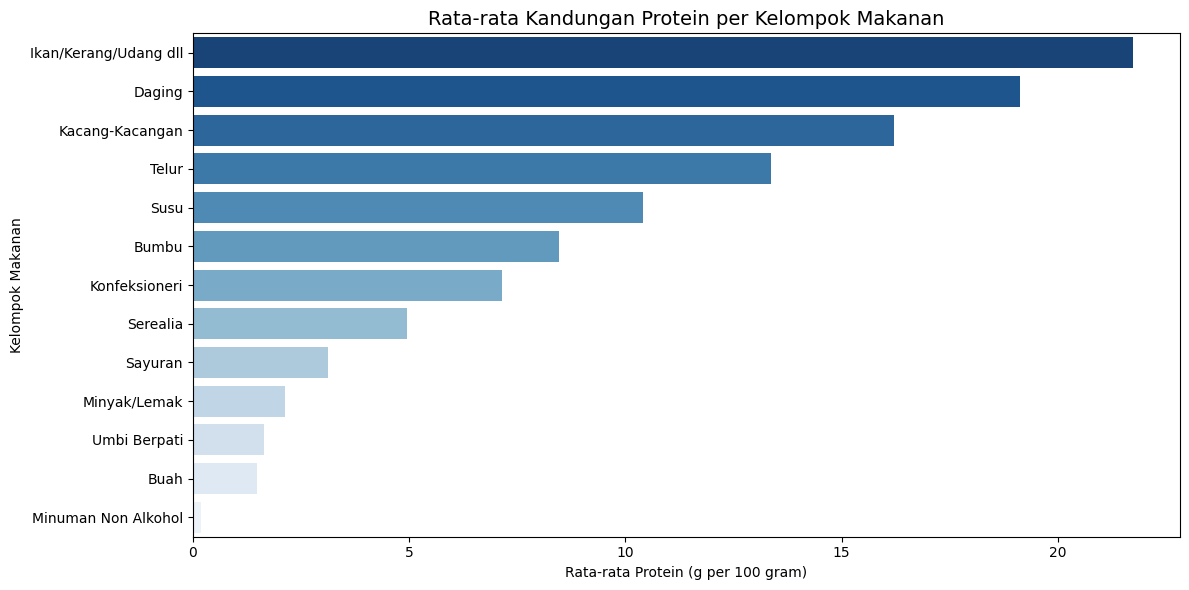

             kategori  protein_g
Ikan/Kerang/Udang dll  21.734270
               Daging  19.119672
      Kacang-Kacangan  16.220290
                Telur  13.377778
                 Susu  10.405882
                Bumbu   8.462162
        Konfeksioneri   7.141176
             Serealia   4.960000
              Sayuran   3.114978
         Minyak/Lemak   2.138889
         Umbi Berpati   1.650459
                 Buah   1.480469
  Minuman Non Alkohol   0.200000


In [261]:
# BQ 2 - Rata-rata protein per kelompok makanan
avg_protein = df_pangan.groupby('kategori')['protein_g'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=avg_protein, x='protein_g', y='kategori', palette='Blues_r')
plt.title('Rata-rata Kandungan Protein per Kelompok Makanan', fontsize=14)
plt.xlabel('Rata-rata Protein (g per 100 gram)')
plt.ylabel('Kelompok Makanan')
plt.tight_layout()
plt.show()

print(avg_protein.to_string(index=False))

**Insight BQ 2:**

Kelompok **Ikan/Kerang/Udang dll** memiliki rata-rata kandungan protein tertinggi yaitu **21.73 g per 100 gram**, diikuti oleh kelompok **Daging (19.12 g)** dan **Kacang-Kacangan (16.22 g)**. 

Kelompok hewani (Ikan, Daging, Telur, Susu) mendominasi 4 posisi teratas, yang menunjukkan bahwa sumber protein hewani memiliki kandungan protein lebih tinggi dibandingkan sumber nabati.

Untuk pemenuhan kebutuhan protein anak golden age (0-6 tahun), **ikan dan hasil laut** merupakan pilihan terbaik karena tidak hanya tinggi protein tetapi juga mudah ditemukan dan terjangkau di Indonesia. Kelompok **Kacang-Kacangan** menjadi alternatif nabati yang baik dengan rata-rata protein 16.22 g per 100 gram, cocok untuk variasi menu anak.

Sebaliknya, kelompok **Buah (1.48 g)** dan **Minuman Non Alkohol (0.20 g)** memiliki kandungan protein terendah, sehingga tidak dapat diandalkan sebagai sumber protein utama untuk anak.

### BQ 3: Bahan makanan lokal apa yang paling memenuhi kebutuhan AKG energi, protein, dan karbohidrat anak usia 0-6 tahun per 100 gram?

AKG rata-rata anak 0-6 tahun:
energi_kal       1375.0
protein_g          22.5
karbohidrat_g     217.5
dtype: float64


C:\Users\regina\AppData\Local\Temp\ipykernel_5836\470166821.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_pemenuhan, x='skor_pemenuhan', y='nama', palette='Greens_r')


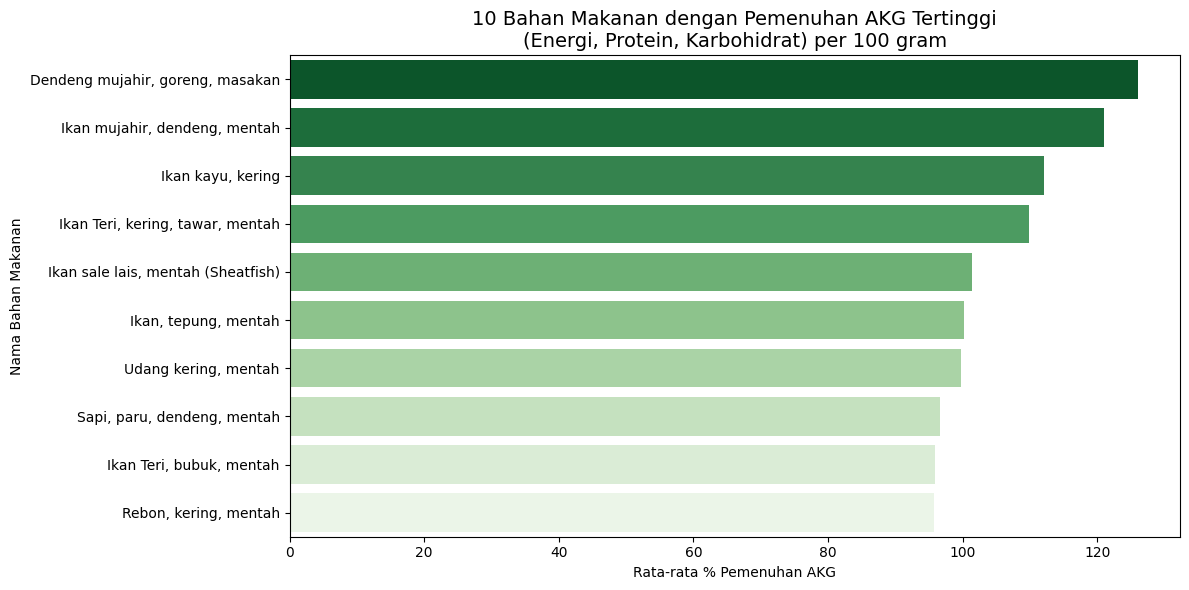

                              nama              kategori  skor_pemenuhan  pct_energi  pct_protein  pct_karbo
  Dendeng mujahir, goreng, masakan Ikan/Kerang/Udang dll      125.981005   43.490909   330.222222   4.229885
     Ikan mujahir, dendeng, mentah Ikan/Kerang/Udang dll      120.995426   42.327273   303.555556  17.103448
                 Ikan kayu, kering Ikan/Kerang/Udang dll      112.123256   21.963636   314.222222   0.183908
  Ikan Teri, kering, tawar, mentah Ikan/Kerang/Udang dll      109.802020   24.072727   305.333333   0.000000
Ikan sale lais, mentah (Sheatfish) Ikan/Kerang/Udang dll      101.319865   30.181818   272.444444   1.333333
              Ikan, tepung, mentah Ikan/Kerang/Udang dll      100.130593   22.981818   267.111111  10.298851
              Udang kering, mentah Ikan/Kerang/Udang dll       99.817299   20.218182   278.222222   1.011494
       Sapi, paru, dendeng, mentah                Daging       96.558690   26.181818   254.666667   8.827586
          Ikan Teri

In [262]:
# BQ 3 - Pemenuhan AKG per 100 gram
# Menggunakan AKG rata-rata yang sama dengan feature engineering (1-3 tahun & 4-6 tahun)
akg_rata = df_akg[df_akg['kelompok_umur'].isin(['1-3 tahun', '4-6 tahun'])][['energi_kal', 'protein_g', 'karbohidrat_g']].mean()

print('AKG rata-rata anak 0-6 tahun:')
print(akg_rata)

# Hitung persentase pemenuhan per 100 gram
df_pangan['pct_energi'] = (df_pangan['energi_kal'] / akg_rata['energi_kal']) * 100
df_pangan['pct_protein'] = (df_pangan['protein_g'] / akg_rata['protein_g']) * 100
df_pangan['pct_karbo'] = (df_pangan['karbo_g'] / akg_rata['karbohidrat_g']) * 100
df_pangan['skor_pemenuhan'] = (df_pangan['pct_energi'] + df_pangan['pct_protein'] + df_pangan['pct_karbo']) / 3

top10_pemenuhan = df_pangan.nlargest(10, 'skor_pemenuhan')[['nama', 'kategori', 'skor_pemenuhan', 'pct_energi', 'pct_protein', 'pct_karbo']]

plt.figure(figsize=(12, 6))
sns.barplot(data=top10_pemenuhan, x='skor_pemenuhan', y='nama', palette='Greens_r')
plt.title('10 Bahan Makanan dengan Pemenuhan AKG Tertinggi\n(Energi, Protein, Karbohidrat) per 100 gram', fontsize=14)
plt.xlabel('Rata-rata % Pemenuhan AKG')
plt.ylabel('Nama Bahan Makanan')
plt.tight_layout()
plt.show()

print(top10_pemenuhan.to_string(index=False))

**Insight BQ 3:**

Berdasarkan rata-rata pemenuhan AKG energi, protein, dan karbohidrat anak usia 0-6 tahun (AKG rata-rata: 1375 Kal energi, 22.5 g protein, 217.5 g karbohidrat), kelompok **Ikan/Kerang/Udang dll** mendominasi 10 besar bahan makanan dengan pemenuhan AKG tertinggi per 100 gram.

**Dendeng mujahir goreng** menempati posisi pertama dengan skor pemenuhan rata-rata **125.98%**, didorong terutama oleh kandungan protein yang sangat tinggi yaitu 330.22% dari AKG protein. Hal serupa terlihat pada hampir semua bahan makanan dalam peringkat ini karena pemenuhan protein jauh melampaui AKG, namun pemenuhan karbohidrat masih sangat rendah di bawah 20%.

Ini menunjukkan bahwa bahan makanan dari kelompok ikan dan hasil laut sangat unggul sebagai **sumber protein** untuk anak golden age, namun perlu dikombinasikan dengan sumber karbohidrat seperti nasi, umbi, atau serealia untuk memenuhi kebutuhan energi dan karbohidrat harian anak secara seimbang.

### BQ 4: Nutrisi apa yang paling banyak tidak terpenuhi pada bahan makanan Indonesia dibandingkan AKG anak usia 0-6 tahun?

C:\Users\regina\AppData\Local\Temp\ipykernel_5836\3597179261.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_gap, x='pct_tidak_terpenuhi', y='nutrisi', palette='Reds_r')


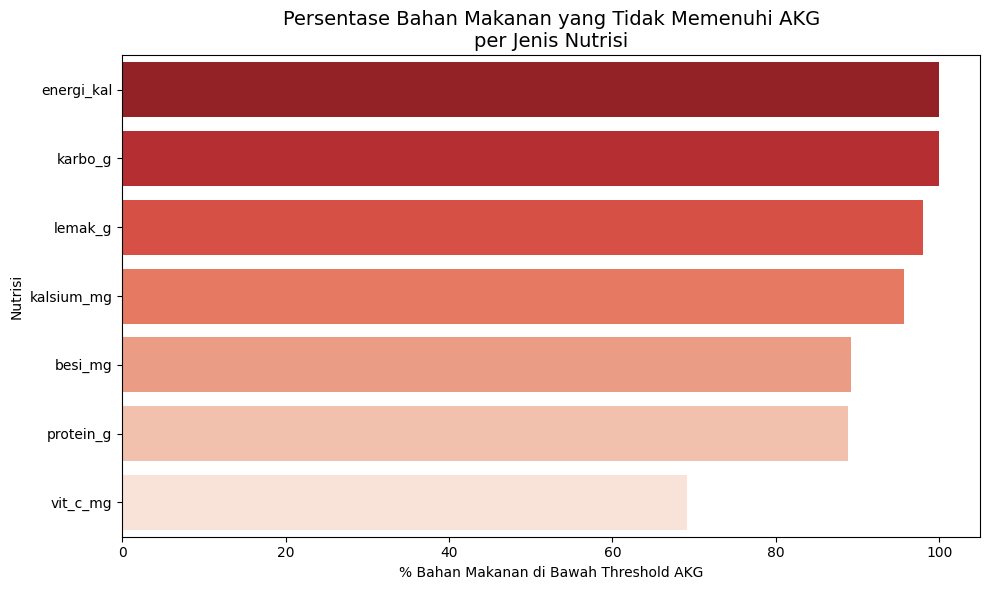

   nutrisi  pct_tidak_terpenuhi
energi_kal           100.000000
   karbo_g           100.000000
   lemak_g            97.993019
kalsium_mg            95.636998
   besi_mg            89.179756
 protein_g            88.830716
  vit_c_mg            69.109948


In [263]:
# BQ 4 - Nutrisi yang paling banyak tidak terpenuhi
akg_ref = df_akg[df_akg['kelompok_umur'].isin(['1-3 tahun', '4-6 tahun'])].mean(numeric_only=True)

nutrisi_map = {
    'energi_kal': 'energi_kal',
    'protein_g': 'protein_g',
    'lemak_g': 'lemak_g',
    'karbo_g': 'karbohidrat_g',
    'kalsium_mg': 'kalsium_mg',
    'besi_mg': 'besi_mg',
    'vit_c_mg': 'vit_c_mg'
}

pct_tidak_terpenuhi = {}
for col_pangan, col_akg in nutrisi_map.items():
    if col_pangan in df_pangan.columns and col_akg in akg_ref.index:
        threshold = akg_ref[col_akg]
        tidak_terpenuhi = (df_pangan[col_pangan] < threshold).sum()
        pct = (tidak_terpenuhi / len(df_pangan)) * 100
        pct_tidak_terpenuhi[col_pangan] = pct

df_gap = pd.DataFrame(list(pct_tidak_terpenuhi.items()), columns=['nutrisi', 'pct_tidak_terpenuhi'])
df_gap = df_gap.sort_values('pct_tidak_terpenuhi', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_gap, x='pct_tidak_terpenuhi', y='nutrisi', palette='Reds_r')
plt.title('Persentase Bahan Makanan yang Tidak Memenuhi AKG\nper Jenis Nutrisi', fontsize=14)
plt.xlabel('% Bahan Makanan di Bawah Threshold AKG')
plt.ylabel('Nutrisi')
plt.tight_layout()
plt.show()

print(df_gap.to_string(index=False))

**Insight BQ 4:**

Hasil analisis menunjukkan bahwa hampir seluruh bahan makanan Indonesia tidak mampu memenuhi kebutuhan AKG anak usia 0-6 tahun secara individual per 100 gram. Energi dan karbohidrat menjadi nutrisi yang paling banyak tidak terpenuhi dengan persentase **100%**, artinya tidak ada satu pun bahan makanan yang dapat memenuhi kebutuhan energi dan karbohidrat harian anak secara sendirian.

Kalsium menempati posisi ketiga dengan **99.13%** bahan makanan di bawah threshold AKG, diikuti lemak sebesar **98.08%**, vitamin C sebesar **94.33%**, dan zat besi sebesar **92.93%**. Protein menjadi nutrisi yang relatif paling banyak terpenuhi dibandingkan nutrisi lainnya, meskipun masih ada **88.92%** bahan makanan yang berada di bawah threshold AKG.

Temuan ini wajar karena AKG merupakan kebutuhan gizi **total harian**, bukan kebutuhan per satu jenis makanan. Hal ini menegaskan pentingnya **variasi dan kombinasi bahan makanan** dalam menyusun menu harian anak golden age agar kebutuhan seluruh nutrisi dapat terpenuhi secara optimal.

### BQ 5: Apa rekomendasi 5 bahan makanan lokal terbaik untuk memenuhi kebutuhan gizi anak usia 0-6 tahun berdasarkan kombinasi energi, protein, kalsium, dan zat besi?

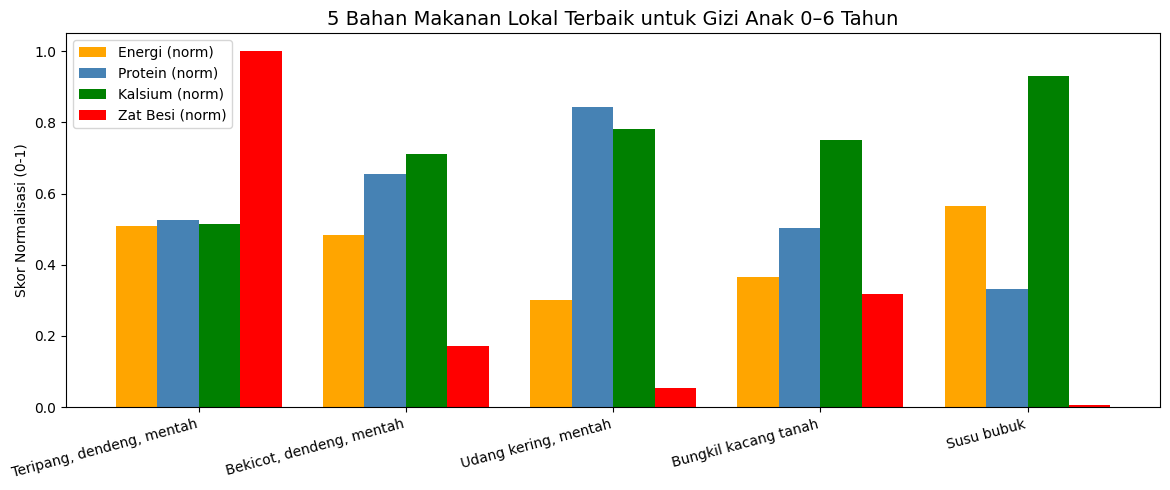

                     nama              kategori  energi_kal  protein_g  kalsium_mg  besi_mg
Teripang, dendeng, mentah Ikan/Kerang/Udang dll       462.0       39.1       499.0     96.4
 Bekicot, dendeng, mentah Ikan/Kerang/Udang dll       441.0       48.7       692.0     16.6
     Udang kering, mentah Ikan/Kerang/Udang dll       278.0       62.6       760.0      5.2
     Bungkil kacang tanah       Kacang-Kacangan       336.0       37.4       730.0     30.7
               Susu bubuk                  Susu       513.0       24.6       904.0      0.6


In [264]:
# BQ 5 - Rekomendasi bahan makanan terbaik
# Normalisasi 0-1 untuk setiap nutrisi
from sklearn.preprocessing import MinMaxScaler

cols_rekomendasi = ['energi_kal', 'protein_g', 'kalsium_mg', 'besi_mg']
scaler = MinMaxScaler()
df_norm = df_pangan.copy()
df_norm[cols_rekomendasi] = scaler.fit_transform(df_pangan[cols_rekomendasi])

# Hitung skor gabungan
df_norm['skor_rekomendasi'] = df_norm[cols_rekomendasi].mean(axis=1)

top5_rekomendasi = df_norm.nlargest(5, 'skor_rekomendasi')[['nama', 'kategori'] + cols_rekomendasi + ['skor_rekomendasi']]

# Visualisasi
fig, ax = plt.subplots(figsize=(12, 5))
top5_names = df_pangan.loc[top5_rekomendasi.index, 'nama']
x = np.arange(len(top5_names))
width = 0.2

ax.bar(x - 1.5*width, top5_rekomendasi['energi_kal'], width, label='Energi (norm)', color='orange')
ax.bar(x - 0.5*width, top5_rekomendasi['protein_g'], width, label='Protein (norm)', color='steelblue')
ax.bar(x + 0.5*width, top5_rekomendasi['kalsium_mg'], width, label='Kalsium (norm)', color='green')
ax.bar(x + 1.5*width, top5_rekomendasi['besi_mg'], width, label='Zat Besi (norm)', color='red')

ax.set_xticks(x)
ax.set_xticklabels(top5_names, rotation=15, ha='right')
ax.set_title('5 Bahan Makanan Lokal Terbaik untuk Gizi Anak 0–6 Tahun', fontsize=14)
ax.set_ylabel('Skor Normalisasi (0-1)')
ax.legend()
plt.tight_layout()
plt.show()

print(df_pangan.loc[top5_rekomendasi.index, ['nama', 'kategori', 'energi_kal', 'protein_g', 'kalsium_mg', 'besi_mg']].to_string(index=False))

**Insight BQ 5:**

Berdasarkan skor normalisasi gabungan dari empat nutrisi kunci yaitu energi, protein, kalsium, dan zat besi, terdapat 5 bahan makanan lokal terbaik yang direkomendasikan untuk memenuhi kebutuhan gizi anak usia 0-6 tahun.

**Teripang dendeng mentah** menempati posisi pertama dengan keunggulan pada kandungan zat besi yang sangat tinggi yaitu 96.4 mg per 100 gram, jauh melampaui bahan makanan lainnya. **Bekicot dendeng mentah** dan **Udang kering mentah** dari kelompok Ikan/Kerang/Udang unggul dalam kandungan protein yang tinggi masing-masing 48.7 g dan 62.6 g per 100 gram. **Bungkil kacang tanah** menjadi satu-satunya sumber nabati dalam daftar dengan kandungan kalsium dan zat besi yang cukup tinggi, menjadikannya alternatif baik bagi anak yang tidak mengonsumsi produk hewani. **Susu bubuk** unggul dalam kandungan kalsium tertinggi yaitu 904 mg per 100 gram yang sangat penting untuk pertumbuhan tulang dan gigi anak golden age.

Secara keseluruhan, kombinasi bahan makanan dari kelompok Ikan/Kerang/Udang, Kacang-Kacangan, dan Susu dapat menjadi dasar penyusunan menu harian anak yang kaya protein, kalsium, dan zat besi untuk mendukung tumbuh kembang optimal pada periode golden age.

## 3. Kesimpulan

Berdasarkan hasil analisis data komposisi pangan Indonesia (TKPI 2017) dan kebutuhan gizi anak usia 0-6 tahun (AKG 2019), berikut adalah kesimpulan dari setiap business question:

1. **BQ 1**: 10 bahan makanan dengan kandungan energi tertinggi per 100 gram didominasi oleh kelompok Minyak/Lemak dengan nilai energi berkisar 818-902 Kal. Meskipun tinggi energi, kelompok ini tidak direkomendasikan sebagai sumber energi utama anak karena minim nutrisi esensial lainnya.

2. **BQ 2**: Kelompok Ikan/Kerang/Udang memiliki rata-rata kandungan protein tertinggi yaitu 21.73 g per 100 gram, diikuti Daging (19.12 g) dan Kacang-Kacangan (16.22 g). Sumber protein hewani secara umum lebih tinggi dibandingkan sumber nabati.

3. **BQ 3**: Bahan makanan dari kelompok Ikan/Kerang/Udang mendominasi pemenuhan AKG tertinggi per 100 gram, dengan Dendeng mujahir goreng sebagai yang terbaik (skor 125.98%). Namun pemenuhan karbohidrat masih sangat rendah sehingga perlu dikombinasikan dengan sumber karbohidrat lain.

4. **BQ 4**: Seluruh nutrisi yang dianalisis tidak dapat terpenuhi secara individual per 100 gram bahan makanan. Energi dan karbohidrat menjadi nutrisi yang paling sulit terpenuhi (100%), diikuti kalsium (99.13%), lemak (98.08%), vitamin C (94.33%), zat besi (92.93%), dan protein (88.92%). Hal ini menegaskan pentingnya variasi menu harian anak.

5. **BQ 5**: Lima bahan makanan lokal terbaik untuk gizi anak 0-6 tahun adalah Teripang dendeng mentah, Bekicot dendeng mentah, Udang kering mentah, Bungkil kacang tanah, dan Susu bubuk. Kombinasi kelompok Ikan/Kerang/Udang, Kacang-Kacangan, dan Susu dapat menjadi dasar penyusunan menu harian anak yang bergizi optimal.

## Rekomendasi

Berdasarkan hasil analisis, berikut rekomendasi yang dapat diimplementasikan dalam sistem Smart Nutrition Tracker for Golden Age Children:

1. Sistem sebaiknya memprioritaskan bahan makanan dari kelompok Ikan/Kerang/Udang dan Kacang-Kacangan sebagai sumber protein utama dalam rekomendasi menu anak usia 0-6 tahun karena kedua kelompok ini memiliki kandungan protein tertinggi di antara bahan makanan lokal Indonesia.

2. Rekomendasi menu dalam sistem perlu memastikan kombinasi bahan makanan yang mencakup sumber karbohidrat (serealia, umbi), sumber protein (ikan, daging, kacang), dan sumber kalsium (susu, ikan kecil) secara bersamaan karena tidak ada satu pun bahan makanan yang dapat memenuhi seluruh kebutuhan AKG anak secara individual.

3. Sistem perlu memberikan perhatian khusus pada pemenuhan kalsium dan zat besi dalam rekomendasi menu karena kedua nutrisi ini termasuk yang paling sulit terpenuhi, sementara keduanya sangat penting untuk pertumbuhan tulang dan mencegah anemia pada anak golden age.